In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
df = pd.read_csv('bank+marketing/bank-additional/bank-additional/bank-additional-full.csv',
                 sep=';', na_values=[''], quotechar='"')

df = df.drop(columns=['y'], errors='ignore')

categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month',
                    'day_of_week', 'poutcome']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

In [4]:
df.head(5)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,False,True,False


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [6]:
sample_size = min(5000, X_scaled.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

K_range = range(2, 16)
silhouette_scores = []
best_k = None
best_score = -1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    labels_sample = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)
    print(f"K = {k:2d} | Silhouette = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nОптимальное K = {best_k} (силуэт = {best_score:.4f})")

K =  2 | Silhouette = 0.2941
K =  3 | Silhouette = 0.0980
K =  4 | Silhouette = 0.0626
K =  5 | Silhouette = 0.0503
K =  6 | Silhouette = 0.0486
K =  7 | Silhouette = 0.0566
K =  8 | Silhouette = 0.0594
K =  9 | Silhouette = 0.0525
K = 10 | Silhouette = 0.0619
K = 11 | Silhouette = 0.0527
K = 12 | Silhouette = 0.0530
K = 13 | Silhouette = 0.0585
K = 14 | Silhouette = 0.0667
K = 15 | Silhouette = 0.0666

Оптимальное K = 2 (силуэт = 0.2941)


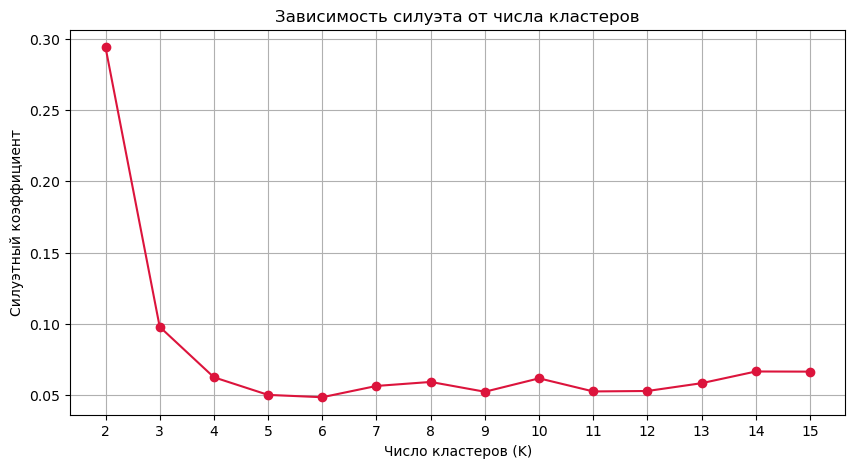

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='crimson')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Зависимость силуэта от числа кластеров')
plt.xticks(K_range)
plt.grid(True)
plt.show()

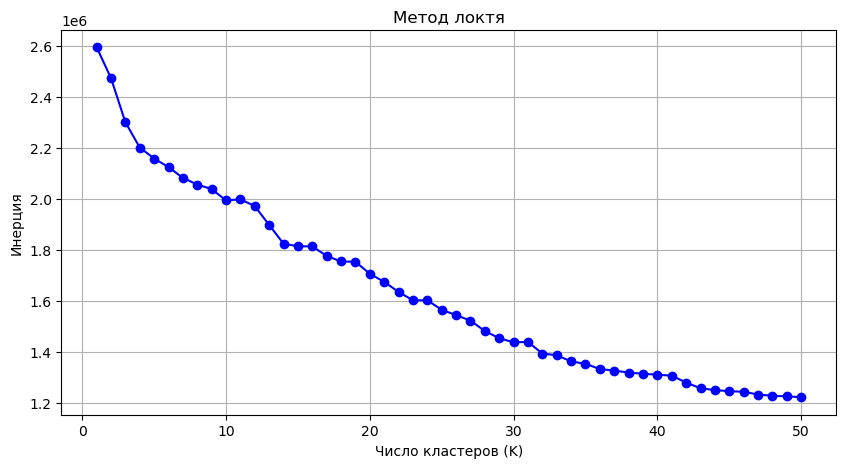

In [8]:
inertia = []
for k in range(1, 51):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), inertia, marker='o', color='blue')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Инерция')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

In [9]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_scaled)
df['cluster'] = cluster_labels

print("\nРаспределение объектов по кластерам:")
print(df['cluster'].value_counts().sort_index())


Распределение объектов по кластерам:
cluster
0    15158
1     1518
2    24512
Name: count, dtype: int64


In [10]:
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'nr.employed']
numeric_cols = [col for col in numeric_cols if col in df.columns]

cluster_profile_mean = df.groupby('cluster')[numeric_cols].mean()
cluster_profile_median = df.groupby('cluster')[numeric_cols].median()

print("\nСредние значения признаков по кластерам:")
print(cluster_profile_mean.round(2))

print("\nМедианные значения признаков по кластерам:")
print(cluster_profile_median.round(2))


Средние значения признаков по кластерам:
           age  duration  campaign   pdays  previous  euribor3m  emp.var.rate  \
cluster                                                                         
0        39.65    260.23      2.07  999.00      0.30       1.80         -1.63   
1        41.84    321.38      1.82    7.98      1.67       0.99         -2.09   
2        40.14    253.18      2.92  999.00      0.00       4.91          1.27   

         cons.price.idx  cons.conf.idx  nr.employed  
cluster                                              
0                 93.03         -42.94      5102.28  
1                 93.34         -38.34      5029.13  
2                 93.93         -39.13      5215.62  

Медианные значения признаков по кластерам:
          age  duration  campaign  pdays  previous  euribor3m  emp.var.rate  \
cluster                                                                       
0        37.0     185.0       2.0  999.0       0.0       1.31          -1.8   
1

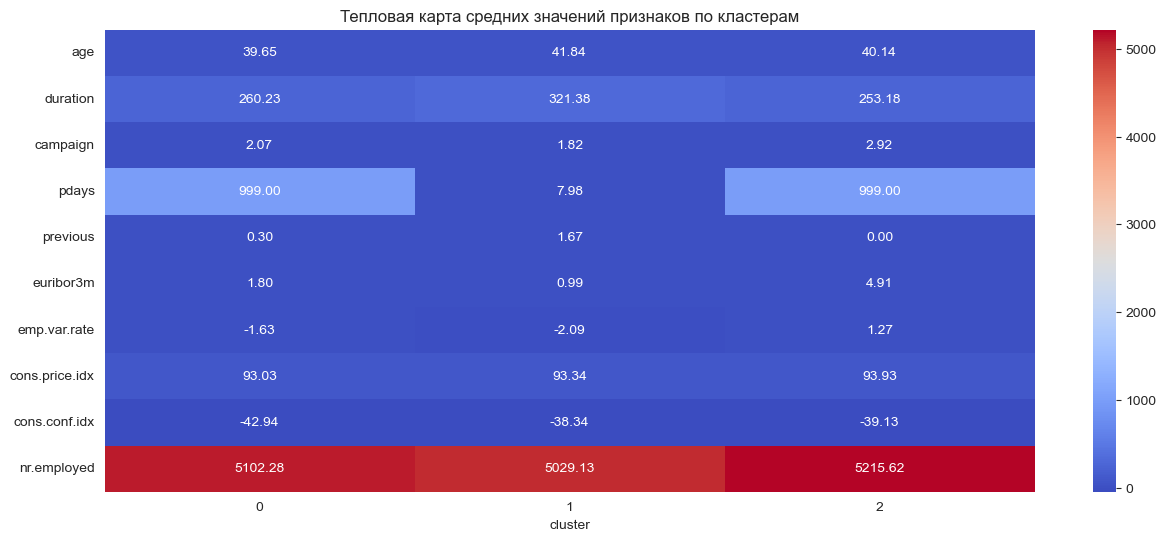

In [11]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(15, 6))
sns.heatmap(cluster_profile_mean.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков по кластерам')
plt.show()

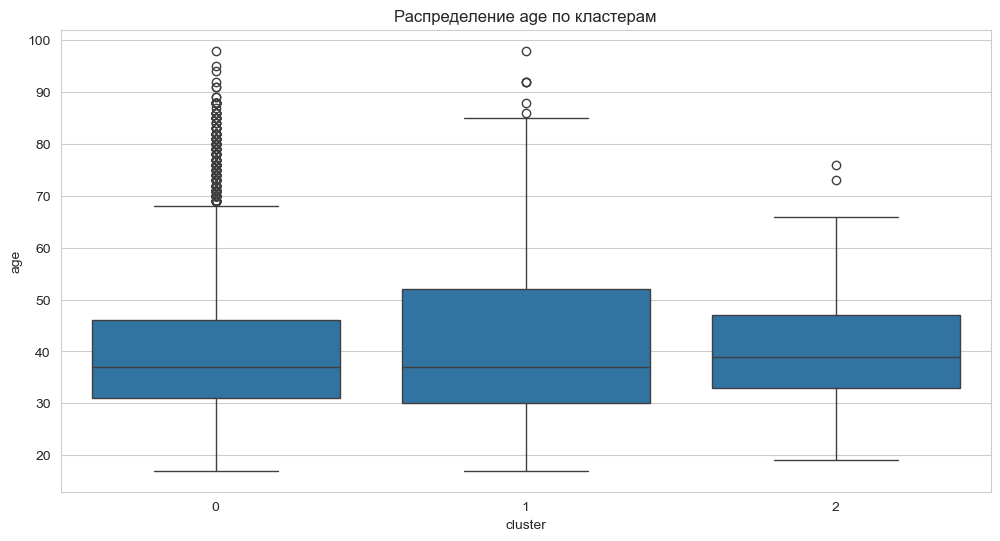

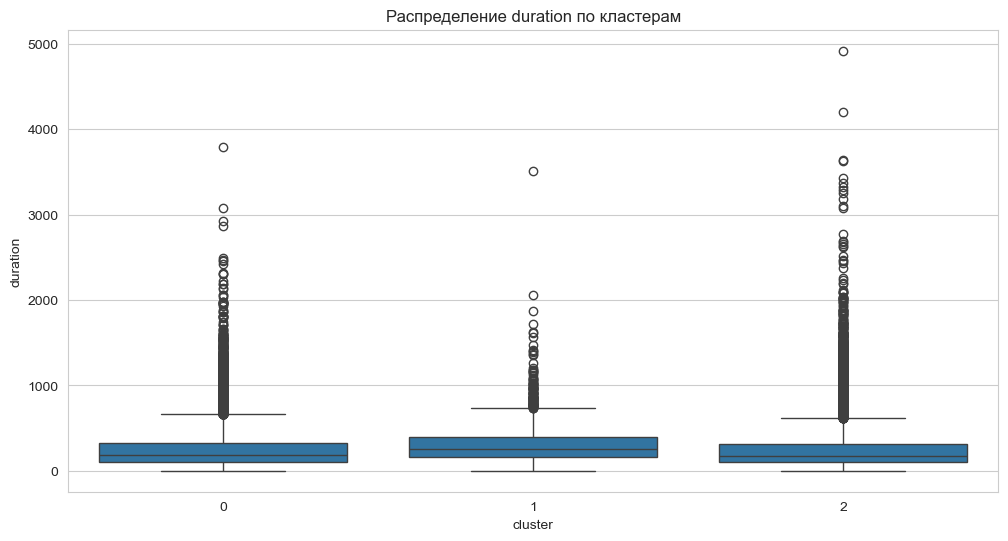

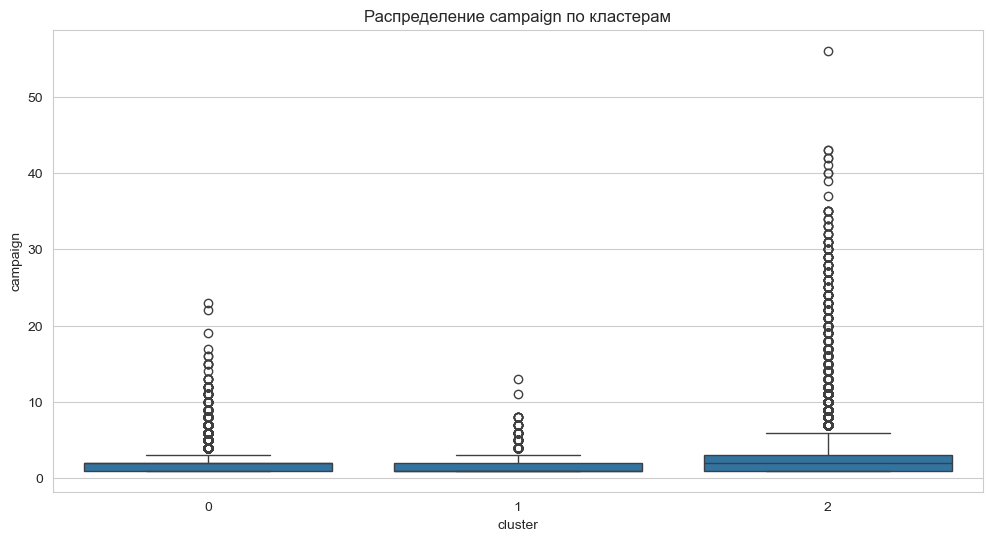

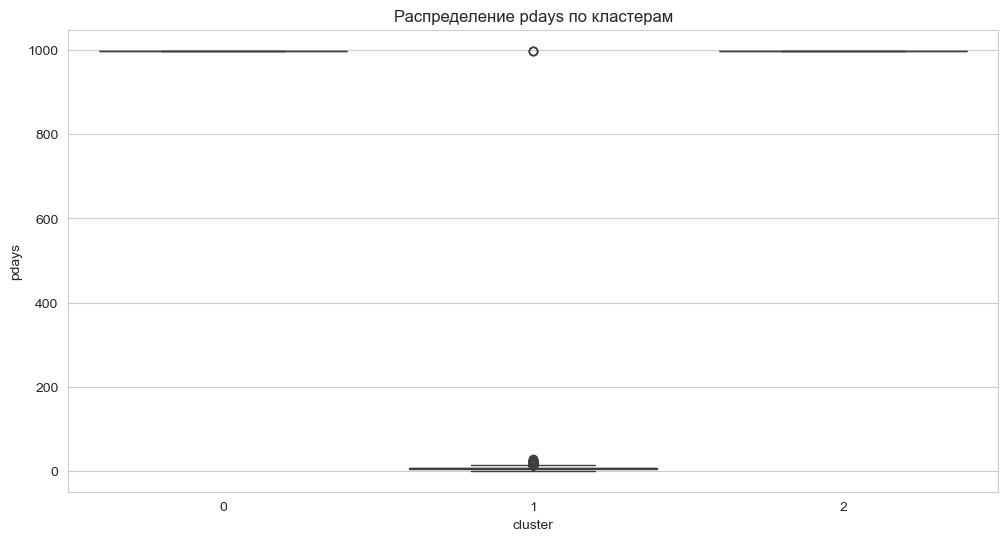

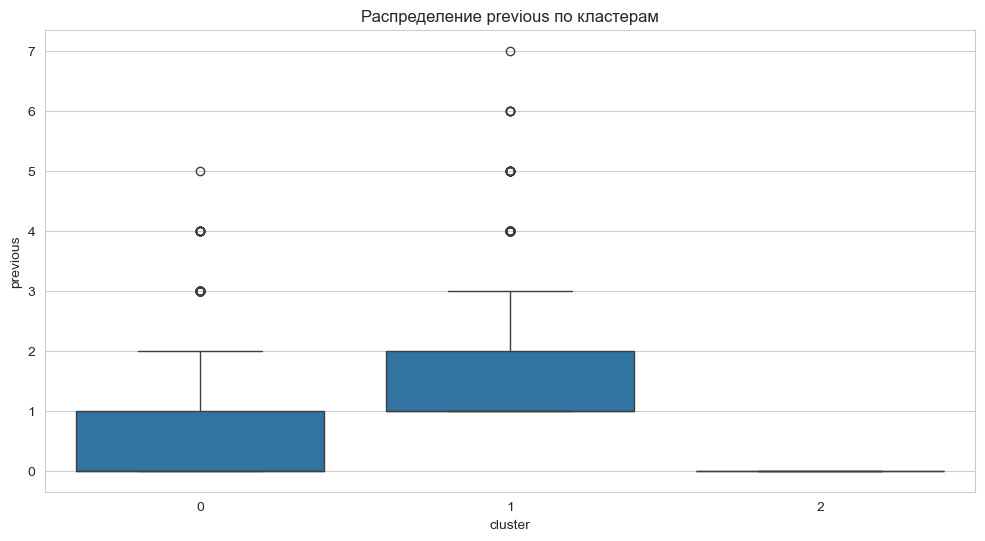

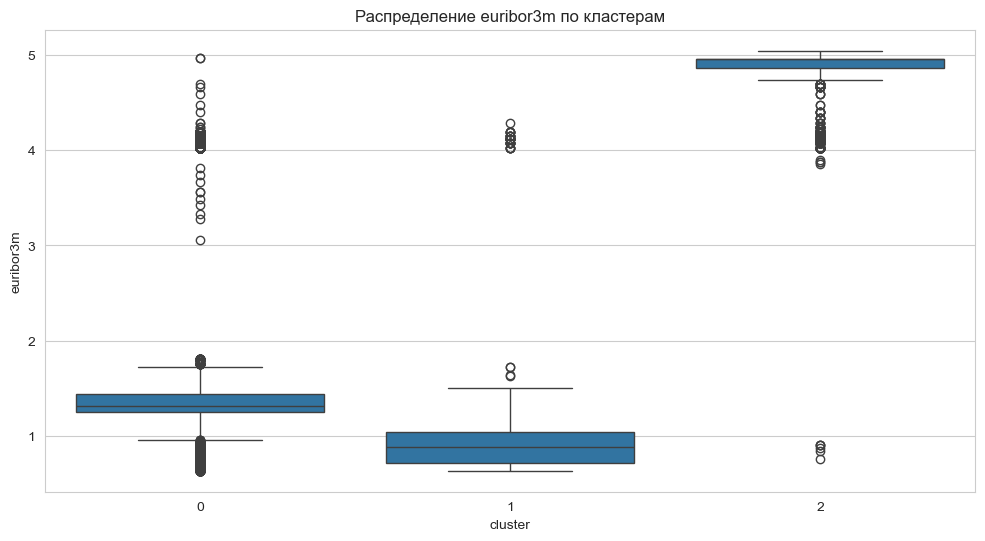

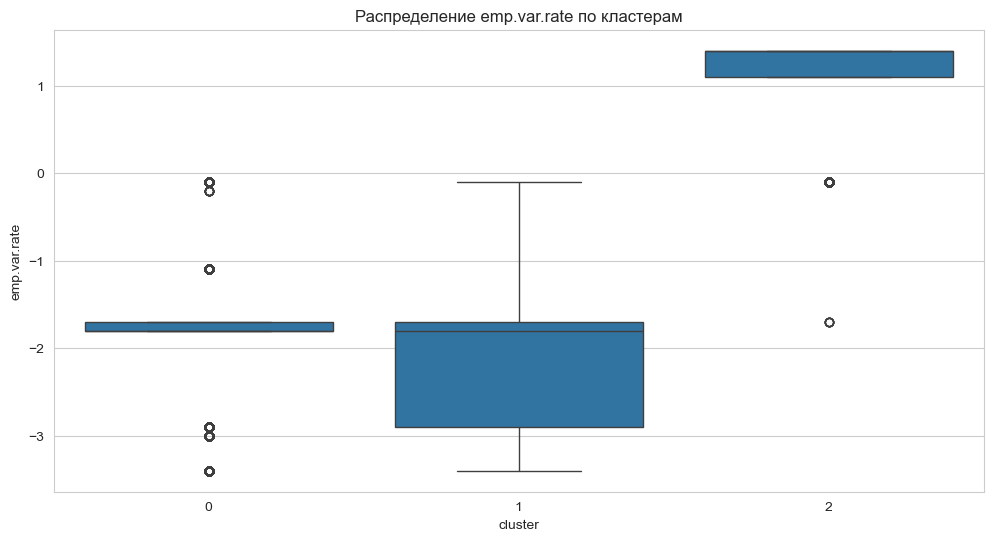

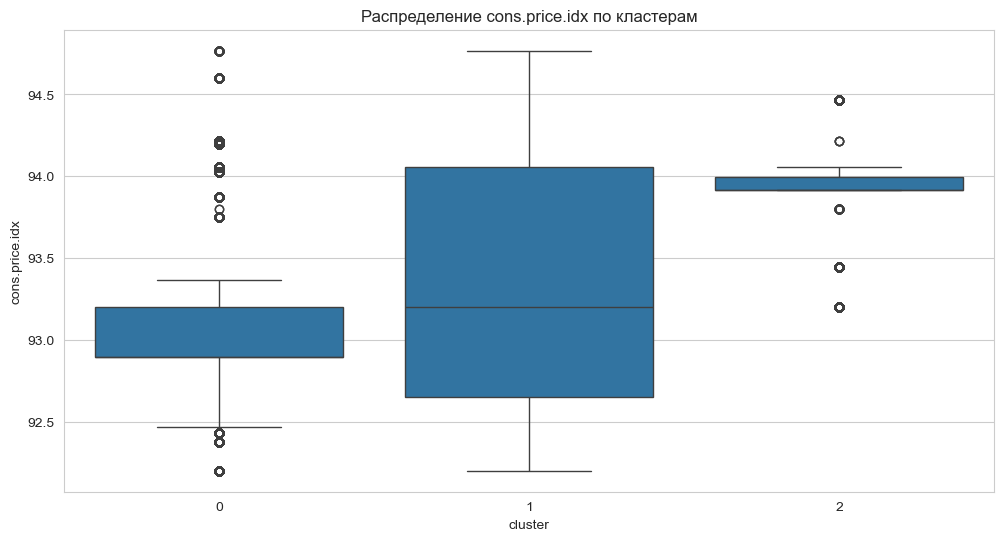

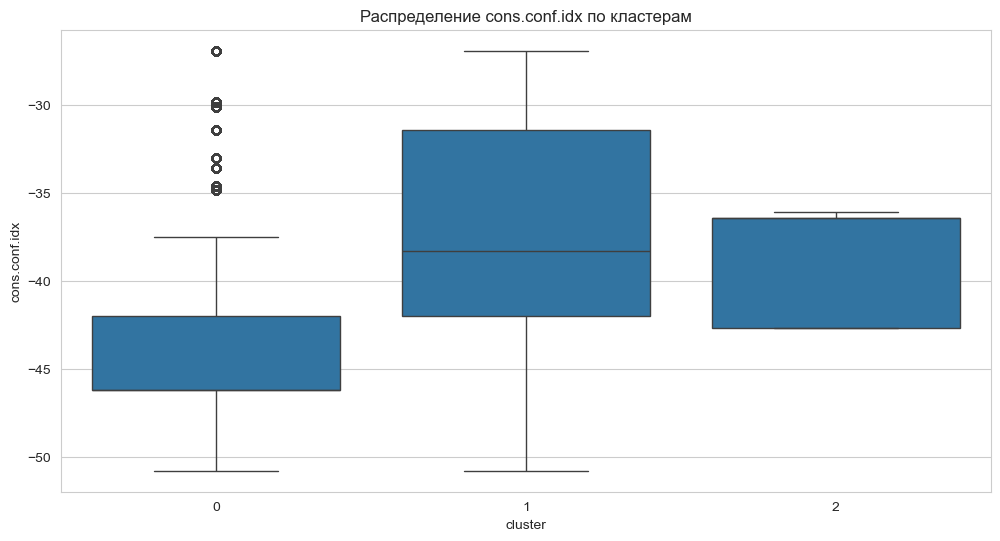

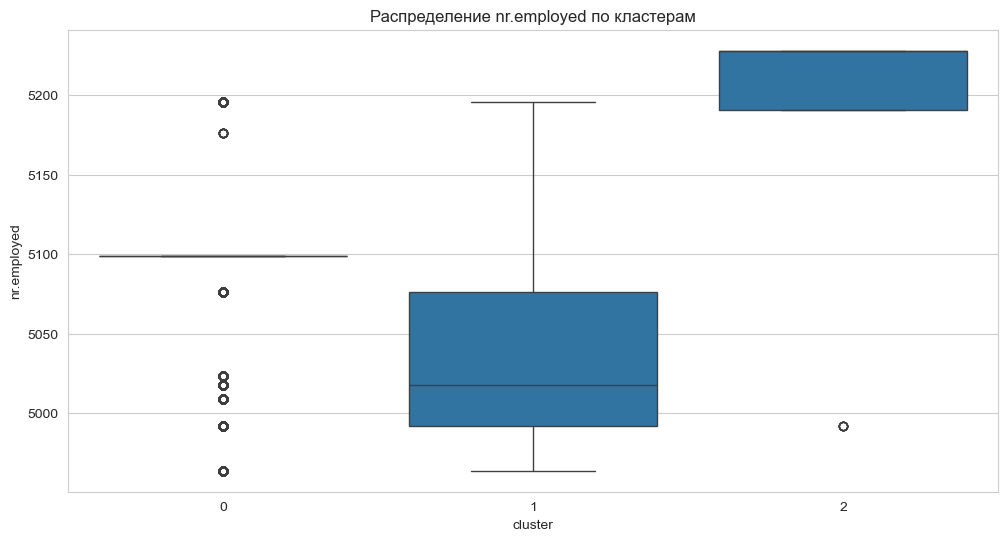

In [12]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x='cluster', y=col)
    plt.title(f'Распределение {col} по кластерам')
    plt.show()

In [13]:
cat_cols = [col for col in df.columns if col not in numeric_cols + ['cluster']]
cluster_cat_profile = df.groupby('cluster')[cat_cols].mean()

print("\nСредние значения признаков (one-hot) по кластерам:")
print(cluster_cat_profile.round(2))


Средние значения признаков (one-hot) по кластерам:
         job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  \
cluster                                                                 
0              0.26             0.21              0.04           0.02   
1              0.31             0.08              0.02           0.03   
2              0.24             0.25              0.03           0.03   

         job_management  job_retired  job_self-employed  job_services  \
cluster                                                                 
0                  0.08         0.05               0.04          0.10   
1                  0.07         0.12               0.02          0.05   
2                  0.06         0.03               0.03          0.10   

         job_student  job_technician  ...  month_oct  month_sep  \
cluster                               ...                         
0               0.04            0.14  ...       0.03       0.03   
1              

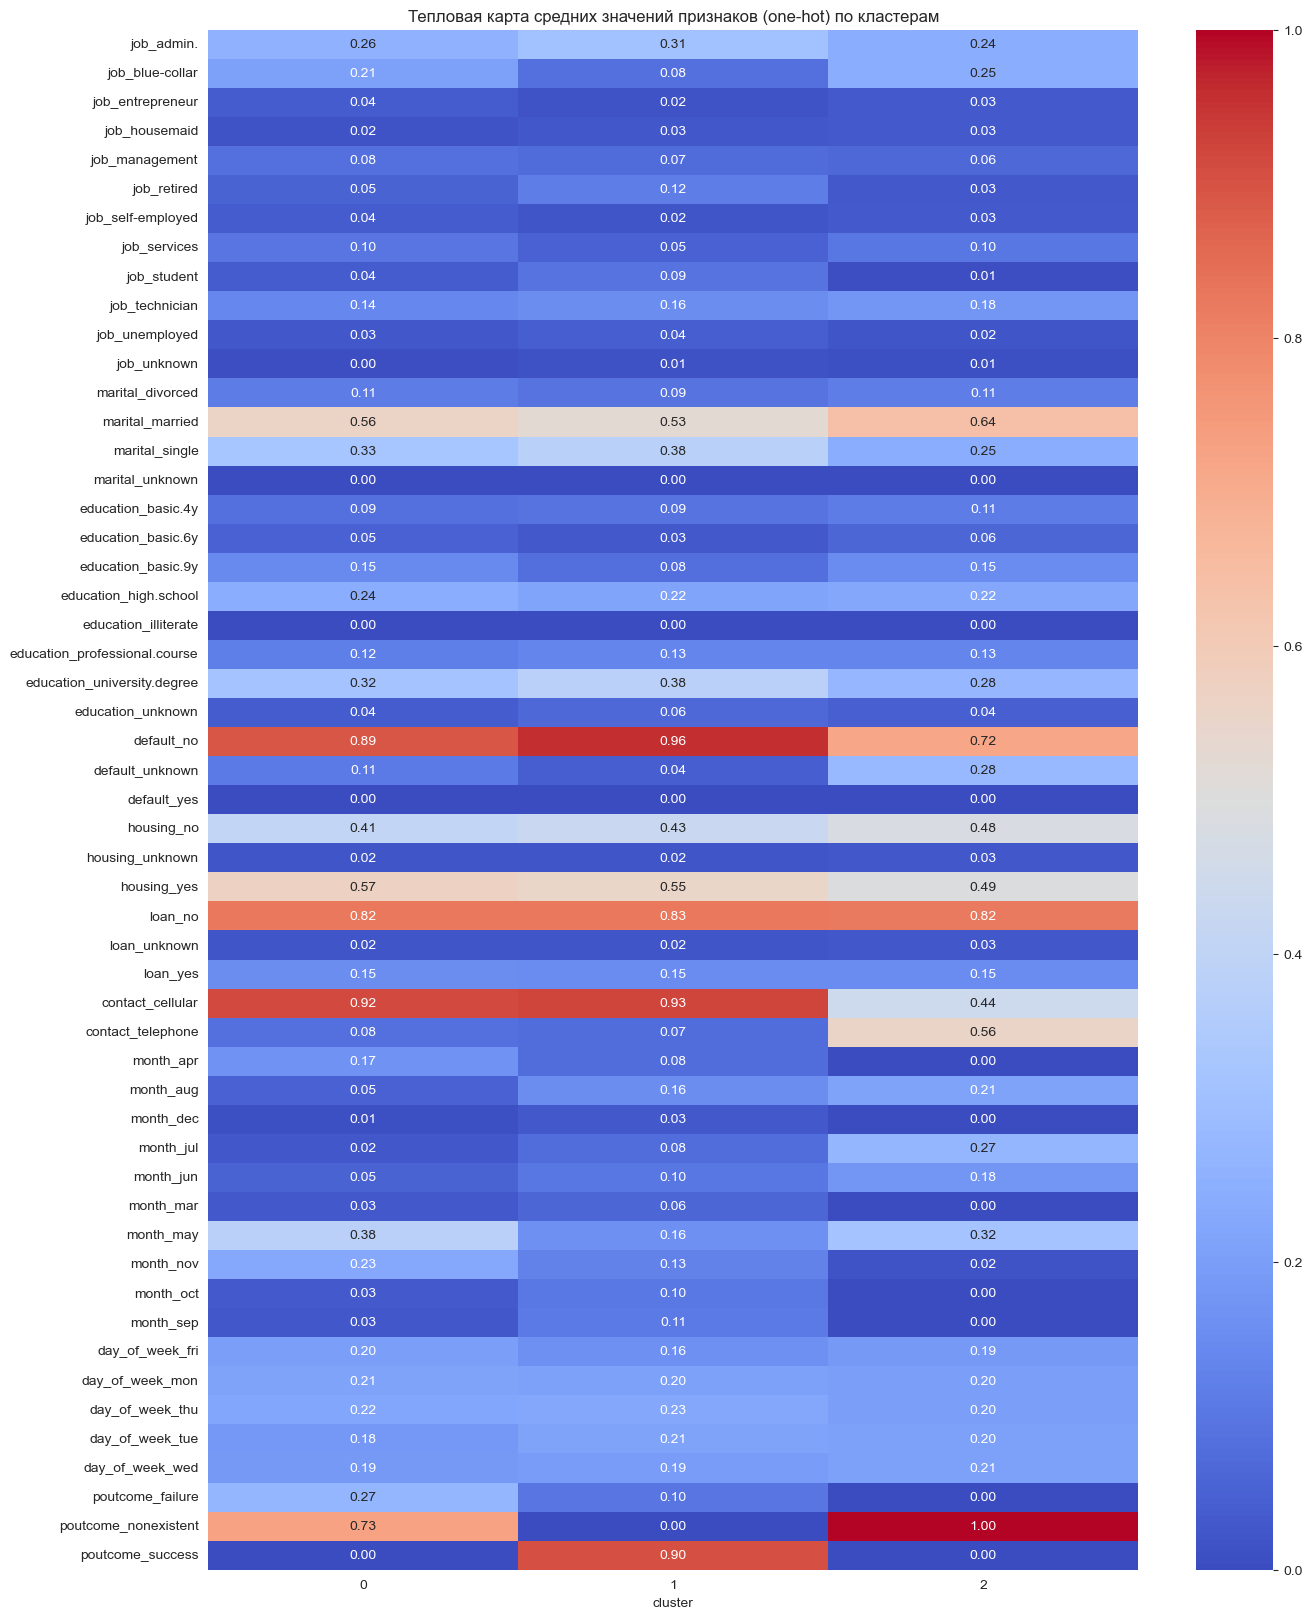

In [14]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(15, 20))
sns.heatmap(cluster_cat_profile.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков (one-hot) по кластерам')
plt.show()

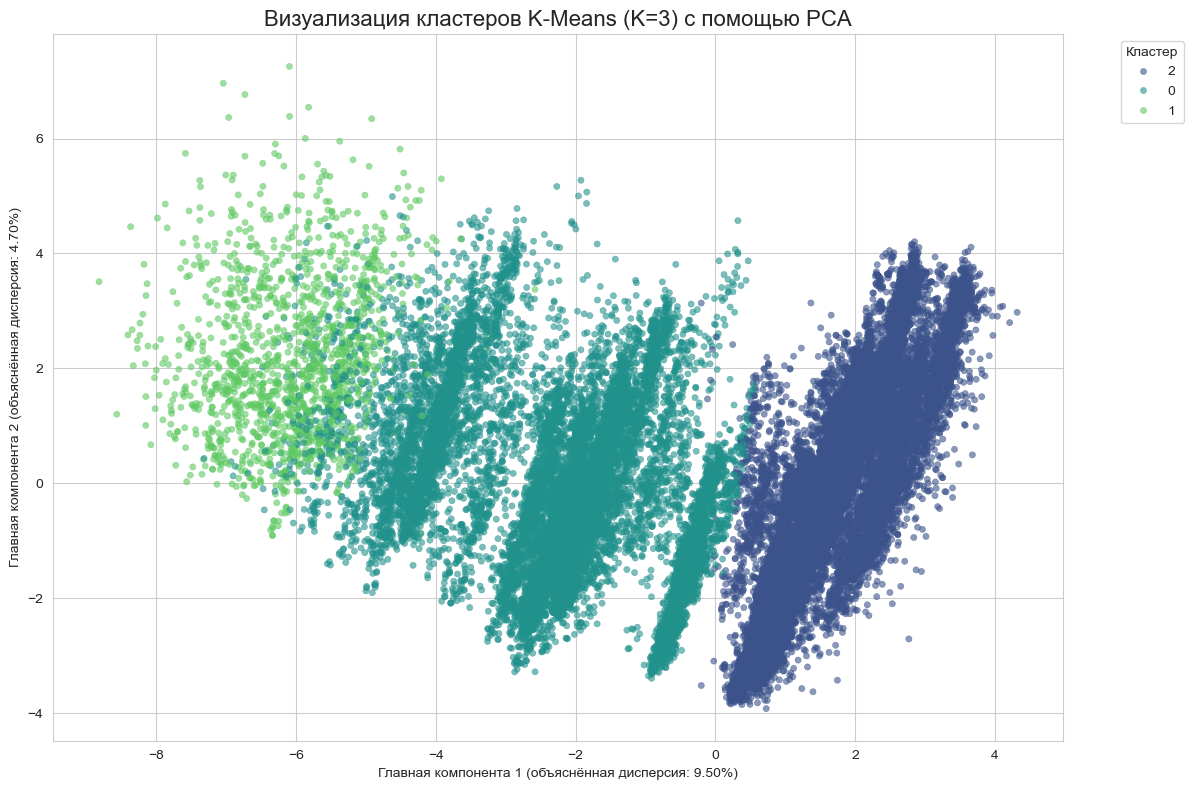

In [15]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df['Cluster'] = cluster_labels.astype(str)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=pca_df,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='viridis',
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'Визуализация кластеров K-Means (K=3) с помощью PCA', fontsize=16)
plt.xlabel(f'Главная компонента 1 (объяснённая дисперсия: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Главная компонента 2 (объяснённая дисперсия: {pca.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.neighbors import NearestNeighbors

pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: объяснённая дисперсия = {pca.explained_variance_ratio_.sum():.2%}")

sample_size = 3000
np.random.seed(42)
sample_idx = np.random.choice(X_pca.shape[0], size=sample_size, replace=False)
X_sample = X_pca[sample_idx]

min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples, metric='euclidean', algorithm='auto')
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
k_distances = distances[:, -1]

eps = np.percentile(k_distances, 90)
print(f"Выбранное eps = {eps:.3f} (90-й перцентиль расстояний до {min_samples}-го соседа)")

PCA: объяснённая дисперсия = 61.92%
Выбранное eps = 5.273 (90-й перцентиль расстояний до 10-го соседа)


In [18]:
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean', algorithm='auto')
labels = dbscan.fit_predict(X_pca)

In [19]:
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"\nКластеров: {n_clusters}, шумовых точек: {n_noise} ({100*n_noise/len(labels):.1f}%)")


Кластеров: 3, шумовых точек: 70 (0.2%)


Силуэт (без шума): 0.3264


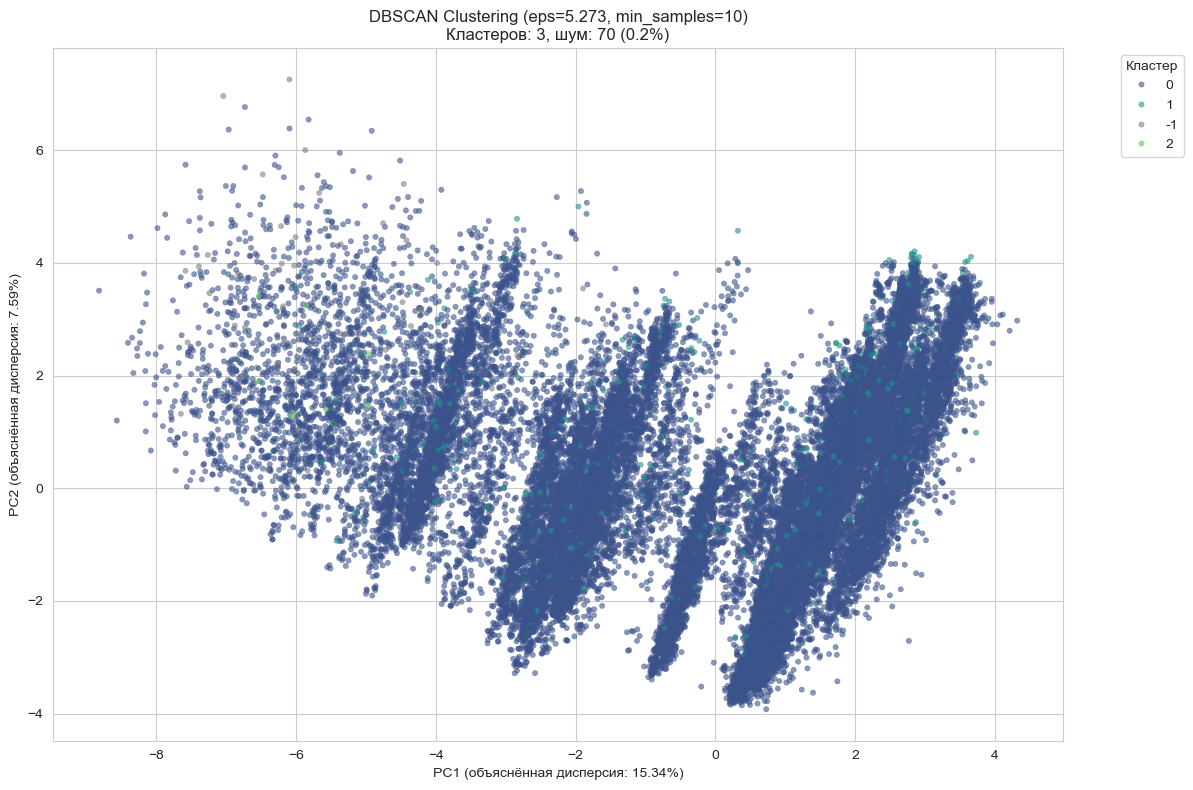

In [20]:
df['cluster_dbscan'] = labels

if n_clusters > 1:
    mask = labels != -1
    if np.sum(mask) > 2:
        sil_score = silhouette_score(X_pca[mask], labels[mask])
        print(f"Силуэт (без шума): {sil_score:.4f}")

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_pca)

pca_df = pd.DataFrame(data=X_2d, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels.astype(str)

palette = {str(i): color for i, color in enumerate(sns.color_palette("viridis", n_clusters))}
palette['-1'] = (0.5, 0.5, 0.5)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Cluster',
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    s=15
)
plt.title(f'DBSCAN Clustering (eps={eps:.3f}, min_samples={min_samples})\n'
          f'Кластеров: {n_clusters}, шум: {n_noise} ({100*n_noise/len(labels):.1f}%)')
plt.xlabel(f'PC1 (объяснённая дисперсия: {pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (объяснённая дисперсия: {pca_2d.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Средние значения признаков по кластерам (без шума):
                  age  duration  campaign   pdays  previous  euribor3m
cluster_dbscan                                                        
0               40.01    258.45      2.57  962.90      0.17       3.62
1               39.77    248.22      2.60  996.90      0.12       3.78
2               36.64    286.93      2.07    5.29      1.36       1.00


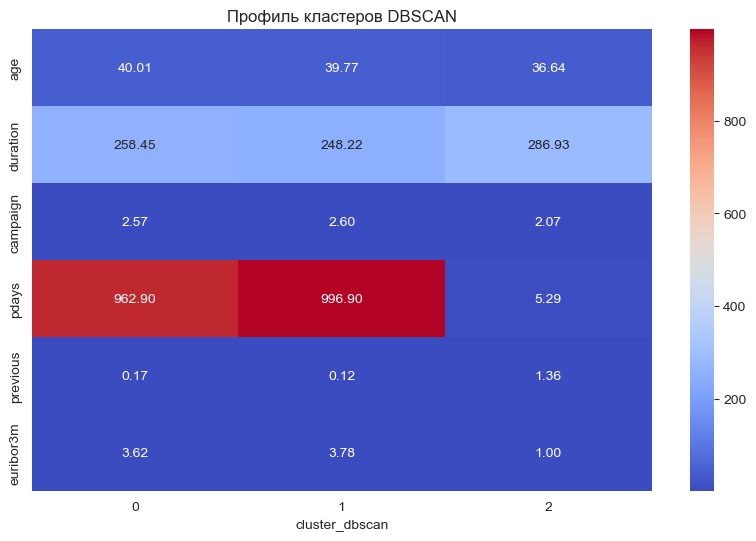

In [21]:
df_no_noise = df[df['cluster_dbscan'] != -1].copy()
if len(df_no_noise) > 0:
    numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m']
    numeric_cols = [col for col in numeric_cols if col in df_no_noise.columns]
    
    cluster_profile = df_no_noise.groupby('cluster_dbscan')[numeric_cols].mean()
    print("\nСредние значения признаков по кластерам (без шума):")
    print(cluster_profile.round(2))

    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_profile.T, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Профиль кластеров DBSCAN')
    plt.show()

In [24]:
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: объяснённая дисперсия = {pca.explained_variance_ratio_.sum():.2%}")

PCA: объяснённая дисперсия = 61.92%


In [25]:
sample_size = 5000
np.random.seed(42)
sample_idx = np.random.choice(X_pca.shape[0], size=sample_size, replace=False)
X_sample = X_pca[sample_idx]

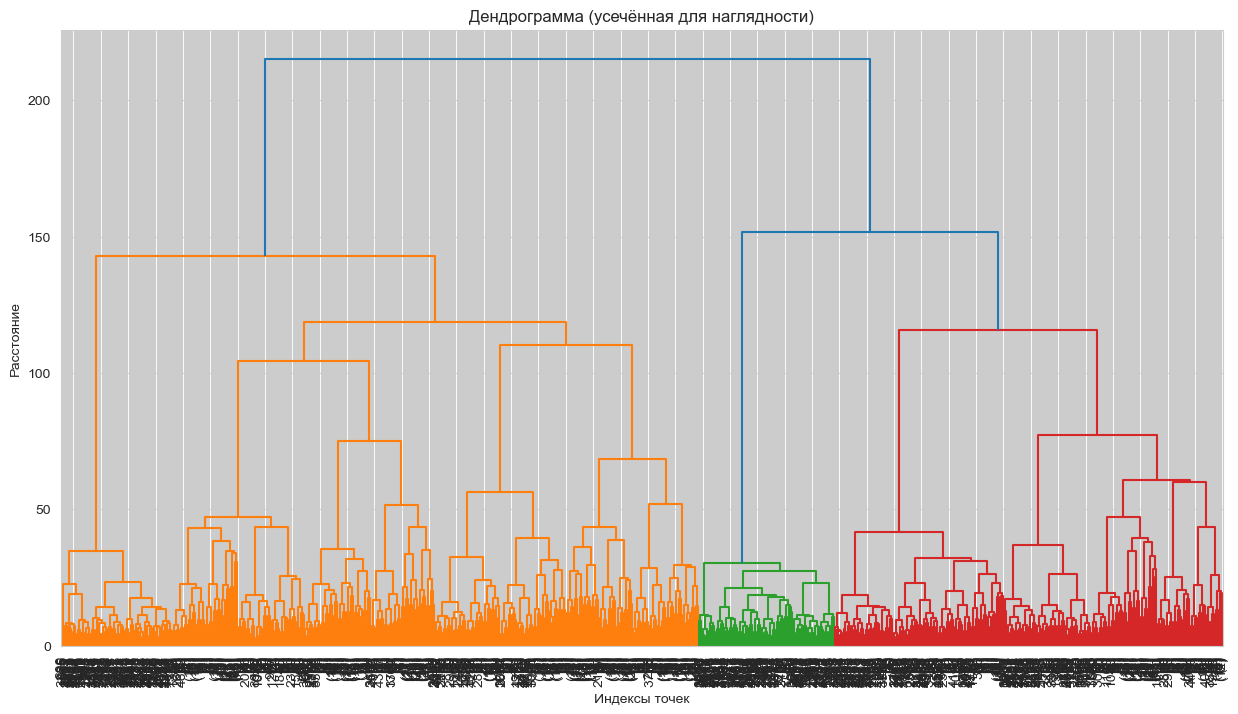

In [26]:
linkage_matrix = linkage(X_sample, method='ward', metric='euclidean')

plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=10, leaf_rotation=90, leaf_font_size=10)
plt.title('Дендрограмма (усечённая для наглядности)')
plt.xlabel('Индексы точек')
plt.ylabel('Расстояние')
plt.show()

In [27]:
K_range = range(2, 15)
sil_scores = []
best_k = 2
best_sil = -1

for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)
    print(f"K={k:2d} | Silhouette = {score:.4f}")
    if score > best_sil:
        best_sil = score
        best_k = k

print(f"\nОптимальное число кластеров по силуэту: K={best_k} (score={best_sil:.4f})")

K= 2 | Silhouette = 0.1434
K= 3 | Silhouette = 0.1404
K= 4 | Silhouette = 0.1556
K= 5 | Silhouette = 0.0955
K= 6 | Silhouette = 0.1070
K= 7 | Silhouette = 0.1058
K= 8 | Silhouette = 0.1050
K= 9 | Silhouette = 0.1098
K=10 | Silhouette = 0.1101
K=11 | Silhouette = 0.0976
K=12 | Silhouette = 0.0993
K=13 | Silhouette = 0.1008
K=14 | Silhouette = 0.1061

Оптимальное число кластеров по силуэту: K=4 (score=0.1556)


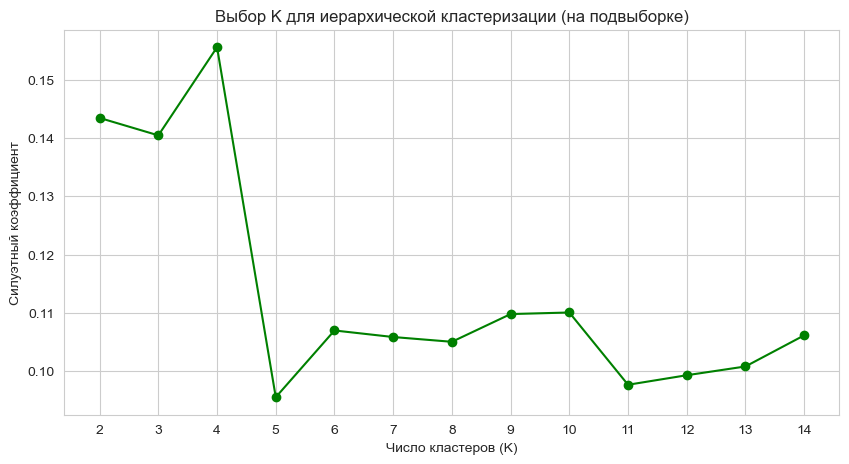

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Выбор K для иерархической кластеризации (на подвыборке)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


Распределение по кластерам:
cluster_agg
0    13592
1    12660
2    13415
3     1521
Name: count, dtype: int64
Силуэт на всех данных: 0.1156


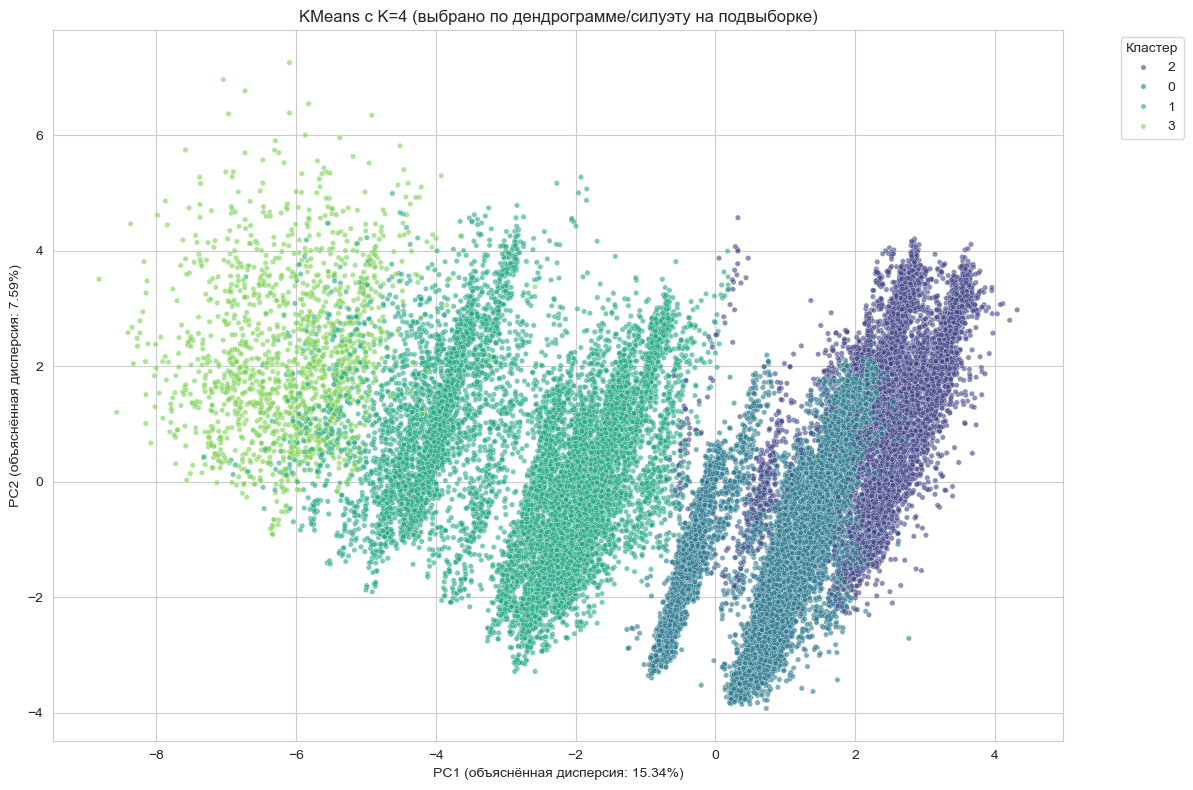

In [29]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
labels_full = kmeans.fit_predict(X_pca)

df['cluster_agg'] = labels_full

print("\nРаспределение по кластерам:")
print(df['cluster_agg'].value_counts().sort_index())

sil_full = silhouette_score(X_pca, labels_full)
print(f"Силуэт на всех данных: {sil_full:.4f}")

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_pca)
pca_df = pd.DataFrame(data=X_2d, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels_full.astype(str)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    alpha=0.6,
    s=15
)
plt.title(f'KMeans с K={best_k} (выбрано по дендрограмме/силуэту на подвыборке)')
plt.xlabel(f'PC1 (объяснённая дисперсия: {pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (объяснённая дисперсия: {pca_2d.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Средние значения признаков по кластерам:
               age  duration  campaign   pdays  previous  euribor3m
cluster_agg                                                        
0            40.08    254.11      2.77  999.00      0.00       4.80
1            39.50    261.45      2.11  999.00      0.36       1.36
2            40.26    252.34      2.88  999.00      0.00       4.86
3            41.83    321.67      1.82    9.93      1.67       0.99


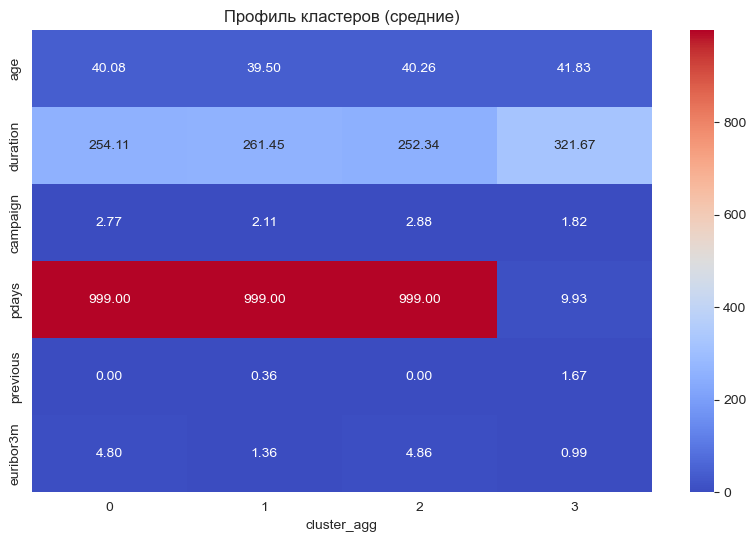

In [30]:
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m']
numeric_cols = [col for col in numeric_cols if col in df.columns]
cluster_profile = df.groupby('cluster_agg')[numeric_cols].mean()
print("\nСредние значения признаков по кластерам:")
print(cluster_profile.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Профиль кластеров (средние)')
plt.show()